# Stellar absorption

An old stellar population puts a broad H$\alpha$ **absorption trough** under the emission line.
In an early-type galaxy the stellar continuum is far brighter than the line-emitting gas, so the
trough eats a real fraction of the line flux -- the fit reports an H$\alpha$ that is too faint, and,
because the trough is not centred on the *gas* velocity, kinematics that are pulled along with it.

`LUCI` gives you two ways to deal with it, and they are for different situations:

| | What it does | Use it when |
|---|---|---|
| **Template** (`luci.background.absorption`) | Stack the spectra of a *stellar* region into one template and subtract it before fitting | The field has somewhere with stellar continuum and no gas to measure |
| **Fitted** (`absorption_bool=True`) | Measure the trough on each spectrum as it is fitted | It does not |

The template is the better instrument where you can build one. This notebook walks through both,
then says plainly what each is worth.

## A cube to work with

Every other example points at a real cube you downloaded. This one builds a small synthetic one so
it runs anywhere -- and, more to the point, so we **know the right answer** and can check what the
two methods recover. It is the same generator the test suite uses.

To use your own cube instead, delete this cell and set `cube = SitelleCube(...)` the way
`BasicExample.ipynb` does.

In [ ]:
import os
import sys
import tempfile

import matplotlib.pyplot as plt
import numpy as np

# The synthetic-cube generator lives with the tests, which is the only place a cube is
# guaranteed to exist on your machine.
REPO = os.path.dirname(os.getcwd())
sys.path.insert(0, os.path.join(REPO, 'tests'))
from fixtures.make_cube import write_cube

from luci import SitelleCube
from luci.config import LINE_DICT

# The continuum is absorbed *entirely* at the trough centre. Deliberately extreme, so the
# trough is unmistakable in the plots below -- a real old population eats more like 0.1-0.4,
# where a single spaxel's depth is noise-dominated (see the closing section).
TRUE_DEPTH = 1.0
TRUE_BROADENING = 200.0    # km/s, the stellar velocity dispersion
TRUE_VELOCITY = 100.0      # km/s, shared by the gas and the stars here

workdir = tempfile.mkdtemp()
truth = write_cube(
    os.path.join(workdir, 'absorption_demo'),
    filter_name='SN3',
    absorption_depth=TRUE_DEPTH,
    absorption_broadening_kms=TRUE_BROADENING,
)

outdir = os.path.join(workdir, 'out')
os.makedirs(outdir, exist_ok=True)

cube = SitelleCube(
    REPO + '/',                      # Luci_path: where ML/ and Data/ live
    truth['path'][:-len('.hdf5')],   # cube path, without the extension
    outdir,
    'ABSDEMO',
    redshift=0.0,
    resolution=5000,
    ML_bool=False,                   # data-driven priors: faster, and plenty here
)

lines = ['Halpha', 'NII6548', 'NII6583']
vel_rel = [1, 1, 1]
sigma_rel = [1, 1, 1]
print('cube', cube.cube_final.shape)

## What the trough looks like

The dashed line is where H$\alpha$ sits. The bowl the emission lines sit in is the stellar
absorption -- broad, centred on the same place as the line that matters, and at this depth
reaching all the way to zero flux at its centre.

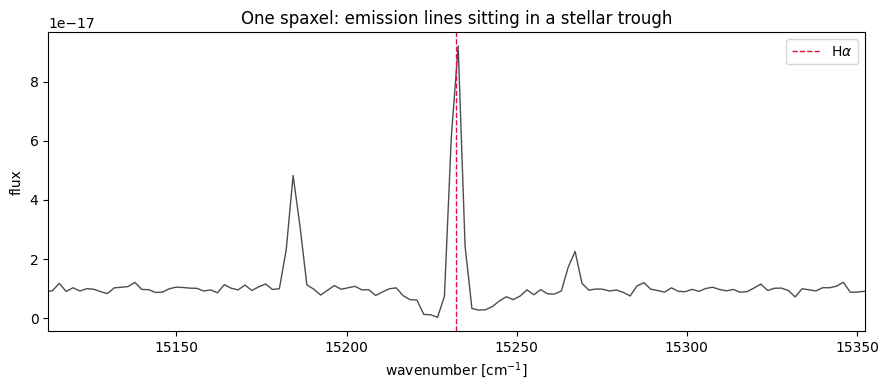

In [18]:
axis = np.asarray(cube.spectrum_axis)
spectrum = cube.cube_final[10, 10, :]
halpha = 1e7 / LINE_DICT['Halpha'] * (1 - TRUE_VELOCITY / 299792)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(axis, spectrum, lw=1, color='0.3')
ax.axvline(halpha, ls='--', color='crimson', lw=1, label=r'H$\alpha$')
ax.set_xlim(halpha - 120, halpha + 120)
ax.set_xlabel(r'wavenumber [cm$^{-1}$]')
ax.set_ylabel('flux')
ax.set_title('One spaxel: emission lines sitting in a stellar trough')
ax.legend()
plt.tight_layout()

---
## 1. The template path

Two steps: build a template from a region, then pass it to any fit as `absorp=`.

**The region has to be starlight without gas.** That is the one thing that makes a template a
*stellar* template: whatever emission is in the region gets stacked into it and then subtracted from
the lines you are trying to measure. Our synthetic cube puts identical emission in every spaxel, so
there is no such region in it -- we generate a second, line-free cube to stand in for one. In a real
field this is a `.reg` file over a starlight-dominated part of the *same* cube, which is why
`build_absorption_template` takes a region.

It also takes a velocity, so it can de-redshift each spaxel before stacking -- otherwise the region's
velocity spread smears the trough out and the template comes back shallower and wider than the real
thing.

**That velocity has to be the stars', not the gas'.** It is tempting to reach for the velocity map a
normal fit writes out (`Luci_outputs/Velocity/..._velocity.fits`) because it is the map you have.
Don't: that is the emission-line velocity of the *gas*, and in an early-type galaxy the gas is
routinely counter-rotating or sitting in a misaligned disk. It is a different velocity field, not a
noisier version of the same one. And remember the region was chosen for having no gas in it -- so an
emission-line fit there is reporting noise, not a velocity.

In preference order:

1. A stellar velocity map. `absorption_velocity`, from the fitted path in section 2, is one.
2. **A single number** -- the region's systemic velocity, which is accepted in place of a map. It
   de-redshifts nothing, so the trough smears by the internal stellar spread, but it never shifts a
   spaxel the *wrong* way. Keep the region small and it costs little.

Every spaxel in this cube shares one velocity, so a single number is exactly right here.

A map, if you pass one, is shaped `(n_y, n_x)` and indexed `[y, x]` -- the orientation LUCI writes
its maps in. Pass one the other way round and you get an error rather than silently wrong velocities.

In [ ]:
# Stands in for a starlight-dominated region of the same cube: same stellar trough, no gas.
stellar_truth = write_cube(
    os.path.join(workdir, 'stellar_only'),
    filter_name='SN3',
    amplitude=0.0,                       # no emission lines
    absorption_depth=TRUE_DEPTH,
    absorption_broadening_kms=TRUE_BROADENING,
)
stellar_cube = SitelleCube(
    REPO + '/', stellar_truth['path'][:-len('.hdf5')], outdir, 'STELLAR',
    redshift=0.0, resolution=5000, ML_bool=False,
)

n_x, n_y = stellar_cube.cube_final.shape[0], stellar_cube.cube_final.shape[1]

# A single systemic velocity, not the emission-line velocity map -- see above. A (n_y, n_x)
# stellar map goes here instead if you have one.
stellar_velocity = TRUE_VELOCITY

# Normally a ds9 .reg file; a boolean mask works too.
stellar_region = np.zeros((n_x, n_y), dtype=bool)
stellar_region[2:18, 2:18] = True

template = stellar_cube.build_absorption_template(stellar_region, stellar_velocity)
print('template on', template.shape[0], 'channels -- the cube spectral axis')

**If you subtract a background, build the template behind the same one.** The template wants to be
the *stellar* continuum, and what is left once the sky comes off is the stellar continuum. Build it
from raw spectra instead and it carries the sky too, which then gets subtracted a second time from a
spectrum the fit has already cleaned. So `build_absorption_template` takes the same `bkg` /
`bkgType` arguments as the fit, and you pass the same values to both.

This cube has no sky and we pass no background, so there is nothing to match here. (If you do use
the PCA background, the same rule applies and matters more -- there the doubled term is per-pixel
and does not cancel at all. `luci/background/absorption.py` has the details.)

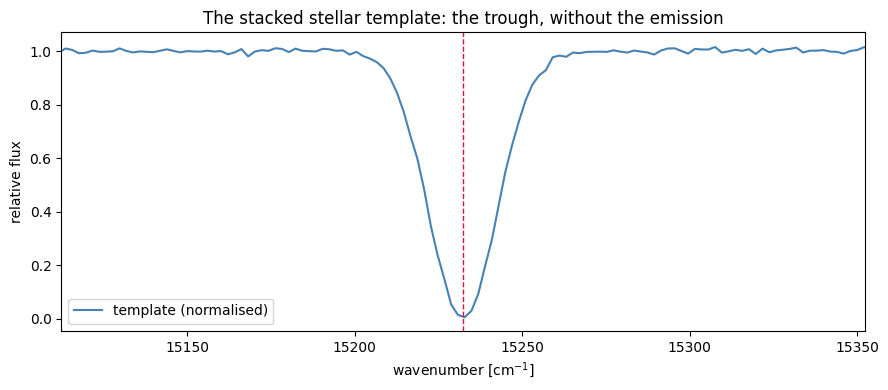

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(axis, template / np.nanmedian(template), lw=1.5, color='steelblue', label='template (normalised)')
ax.axvline(halpha, ls='--', color='crimson', lw=1)
ax.set_xlim(halpha - 120, halpha + 120)
ax.set_xlabel(r'wavenumber [cm$^{-1}$]')
ax.set_ylabel('relative flux')
ax.set_title('The stacked stellar template: the trough, without the emission')
ax.legend()
plt.tight_layout()

Now fit with and without it. `absorp=` is accepted by `fit_cube`, `fit_region`, `fit_pixel`,
`fit_spectrum_region`, `fit_wvt` and `wvt_fit_region` -- every entry point.

In [21]:
_, _, flux_plain, _ = cube.fit_cube(
    lines, 'sincgauss', vel_rel, sigma_rel, 9, 13, 9, 13, n_threads=1)
flux_plain = np.array(flux_plain, copy=True)

_, _, flux_corrected, _ = cube.fit_cube(
    lines, 'sincgauss', vel_rel, sigma_rel, 9, 13, 9, 13, absorp=template, n_threads=1,
    output_name='ABSDEMO_template')
flux_corrected = np.array(flux_corrected, copy=True)

gain = np.nanmean(flux_corrected[..., 0]) / np.nanmean(flux_plain[..., 0])
print('mean Halpha flux, no correction : %.4g' % np.nanmean(flux_plain[..., 0]))
print('mean Halpha flux, template out  : %.4g' % np.nanmean(flux_corrected[..., 0]))
print('change: %+.1f%%' % (100 * (gain - 1)))

INFO luci.cube: New deep frame created from data.
100%|██████████| 4/4 [00:14<00:00,  3.54s/it]

mean Halpha flux, no correction : 1.028e-16
mean Halpha flux, template out  : 1.149e-16
change: +11.7%


About 12%, from a trough that removes the continuum *completely* at its centre. That ratio is the
fixture's doing rather than the method's: its emission lines are around ten times the continuum, so
even total absorption of the continuum is a modest fraction of the line.

In an elliptical it is the other way round -- the continuum dominates the gas, and a trough of a
tenth its depth eats a far larger share of the line flux than what you just saw. That asymmetry is
the whole reason this machinery exists, and it means the *fractional* gain here understates what the
correction is worth on the galaxies you would actually reach for it.

`output_name='ABSDEMO_template'` on the second call is worth noting: without it both fits derive
their filenames from the object name alone and the second overwrites the first.

---
## 2. The fitted path

When there is nowhere to build a template from, `absorption_bool=True` measures the trough on each
spectrum instead, fills it in, and refits the lines. It reports three numbers alongside the usual
ones.

**One number it cannot measure is the width.** The trough is centred on the emission line, so the
channels where it is deepest are the ones the emission occupies and the mask removes. With no noise
the width is recoverable; at real noise the $\chi^2$ penalty for getting it wrong by half again is
about a fifth of the noise floor, so the data cannot choose it. Left free, noise picks it and the
depth slides along with it -- roughly **depth $\propto$ 1/width**. Told 300 km/s against a true 200,
a 0.30 trough reads 0.21; told 100, it reads 0.55.

So the width is supplied, via `absorption_broadening_kms`. Do not guess it, and in particular do not
look up the galaxy's stellar velocity dispersion and use that -- the observed trough is the
population's intrinsic H$\alpha$ profile convolved with $\sigma$ *and* the instrument, so it is wider
than $\sigma$ alone, and understating the width overstates the depth.

**Measure it from a template instead.** That is a one-liner, because a template has no emission in it
and stacks a whole region: nothing is masked, the trough's peak is right there, and width separates
from depth cleanly. This is the measurement the per-spaxel fit cannot make for itself.

In [ ]:
width = stellar_cube.measure_absorption_width(template)
print('stellar width measured from the template: %.0f km/s' % width)
print('(the fixture built it at %.0f)' % TRUE_BROADENING)

Hand that to the fits. Note what is *not* in the call: `absorp=`. The template path and the fitted
path both remove the same trough, so running them together corrects twice -- LUCI warns if you do.
Here the template is used only to measure the width, and the per-spaxel fit does the removing.

(If you do pass a template *and* `absorption_bool=True`, the width is taken from the template
automatically rather than defaulting -- but the fitted stage will then find nothing left to fit.)

In [ ]:
_, _, plain = cube.fit_pixel(lines, 'sincgauss', vel_rel, sigma_rel, 10, 10)
_, _, fitted = cube.fit_pixel(
    lines, 'sincgauss', vel_rel, sigma_rel, 10, 10,
    absorption_bool=True, absorption_broadening_kms=width)

print('injected   depth %.3f  velocity %5.1f km/s  broadening %5.1f km/s'
      % (TRUE_DEPTH, TRUE_VELOCITY, TRUE_BROADENING))
print('recovered  depth %.3f  velocity %5.1f km/s  broadening %5.1f km/s  (broadening = the input)'
      % (fitted['absorption_depth'], fitted['absorption_velocity'], fitted['absorption_broadening']))
print()
print('Halpha flux  %.4g -> %.4g' % (plain['fluxes'][0], fitted['fluxes'][0]))
print('Halpha vel   %.1f -> %.1f km/s (truth %.1f)'
      % (plain['velocities'][0], fitted['velocities'][0], TRUE_VELOCITY))

Over a cube it writes three extra maps next to the usual products.

In [ ]:
cube.fit_cube(
    lines, 'sincgauss', vel_rel, sigma_rel, 9, 13, 9, 13,
    absorption_bool=True, absorption_broadening_kms=width,
    n_threads=1, output_name='ABSDEMO_fitted')

written = sorted(f for f in os.listdir(cube.output_dir) if 'absorption' in f)
print('\n'.join(written))

depth map: median 1.025, injected 1.000


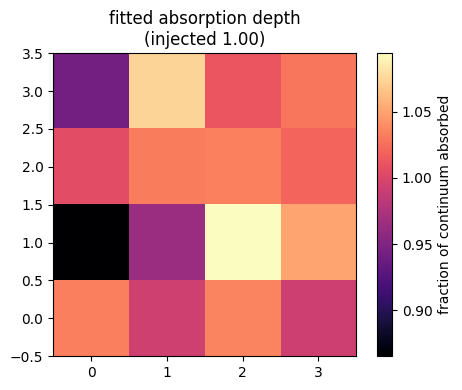

In [24]:
from astropy.io import fits

# Read the name from the listing rather than assembling it: save_fits decorates the base name
# with the binning and fit function, so it depends on how the fit was called.
depth_name = next(f for f in written if f.endswith('absorption_depth.fits'))
depth_map = fits.open(os.path.join(cube.output_dir, depth_name))[0].data

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(depth_map, origin='lower', cmap='magma')
ax.set_title('fitted absorption depth\n(injected %.2f)' % TRUE_DEPTH)
fig.colorbar(im, ax=ax, label='fraction of continuum absorbed')
plt.tight_layout()
print('depth map: median %.3f, injected %.3f' % (np.nanmedian(depth_map), TRUE_DEPTH))

---
## 3. What each is worth

The fitted method recovered 0.96 here against 1.00 injected, and the map median came out 1.02. Those
straddle the truth rather than sitting below it, and that is the whole story: **the method is
unbiased, and its limit is precision, not accuracy.**

What sets the precision is the continuum noise, not the trough. Measured over 400 noise realisations,
the scatter on the depth follows a simple rule from 1% to 10% noise:

$$\sigma_{\rm depth} \approx 0.7 \times \frac{\rm continuum\ noise}{\rm continuum}$$

So a shallow trough is not a problem in itself -- a shallow trough in a *noisy continuum* is. This
fixture is deliberately noisy (10% per channel, continuum S/N of 10), which is the worst case. For an
injected depth of 0.10:

| continuum S/N | recovered | scatter | |
|---|---|---|:--|
| 10 | 0.125 | 0.201 | unusable, and biased high |
| 20 | 0.098 | 0.036 | marginal |
| 50 | 0.099 | 0.015 | fine |
| 100 | 0.099 | 0.007 | fine |

At S/N 10 the scatter has overtaken the signal, and because a depth cannot come back negative the
distribution piles up against zero and drags the mean *up* -- 0.125 for a true 0.10. Two sigma of
headroom and that bias is gone: at S/N 20 the same trough returns 0.098.

That gives two requirements you can check before trusting a map, per spaxel:

- a 3$\sigma$ detection of a trough of depth $d$ needs continuum S/N $\gtrsim 2/d$
- measuring $d$ to 20% needs continuum S/N $\gtrsim 3.5/d$

Both relax as $\sqrt{N}$ when you average, so a WVT bin of 100 spaxels turns S/N 10 into an effective
100. A depth of 0.1 -- where a real old population sits -- is therefore perfectly measurable on a
bright elliptical or in a binned map, and hopeless on a single faint spaxel. Check which you have.
Two things that genuinely do *not* affect it, both measured rather than assumed:

- **Emission brightness.** Recovered depth is unchanged with lines from 0 to 30 times the continuum.
  The mask around the fitted line positions does its job.
- **Noise-free accuracy.** With no noise the estimator returns the injected depth and velocity exactly.

What *does* matter is the width -- which is why section 2 measured it from the template rather than
leaving you to supply it. Since depth $\propto$ 1/width, the error carries straight through: a trough
that is really 310 km/s wide, read at the 200 km/s default, gives a depth of 0.41 where the truth is
0.30. Measuring the width first gives 0.26, inside the per-spaxel scatter.

For the quantity you probably care about -- the line flux -- the rule is that the error in your
correction is the error in your width, scaled by how big the correction was:

$$\frac{\Delta F}{F} \approx \frac{\Delta w}{w} \times (\text{size of the correction})$$

So on a cube where the trough is worth 3% of the H$\alpha$ flux, even a 50% width error costs you
1.5% and you can stop worrying. On an elliptical where it is worth 40%, the same error costs 20% and
the width is the single most important number in the calculation. Measure it.

The **template** path measures the trough on starlight rather than under an emission line, and stacks
many spaxels while doing it, so it is both better constrained and independent of these limits. Where
the field gives you somewhere to stack, prefer it, and use the fitted component as a cross-check.
Both default to off; an ordinary fit is unaffected by either.

### Where to read more

- `luci/background/absorption.py` -- the template: how the de-redshifted stack works, and why a
  background has to come off first
- `luci/fitting/absorption.py` -- the fitted component: why the width cannot be measured from the
  spectrum being fitted (though it can from a template), and the four designs tried before that was
  clear